In [22]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np

from common import (
    CASE_NAMES,
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    format_dataset_title,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)


def compute_qps(metrics: dict) -> float:
    """Compute QPS from serial_latencies (seconds)."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return 1.0 / np.mean(latencies)


# ---------------------------------------------------------------------------
# 1. Load all result JSONs from the index_search results directory
# ---------------------------------------------------------------------------
records = []

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_search/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Parse db_label JSON to get global_version
        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "db_type": "DuckDB",
        })

# Load pgvector results (if available)
pgvector_results_dir = pathlib.Path("../experiments/results/index_search/pgvector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json")) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        index_name = transform_pgvector_index_name(db_case_cfg)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "db_type": "pgvector",
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 370 results from 275 DuckDB files and 95 pgvector files


[{'recall': 1.0,
  'serial_qps': np.float64(4.4079317039970105),
  'index': 'DuckDB',
  'case_id': 502,
  'db_type': 'DuckDB'},
 {'recall': 1.0,
  'serial_qps': np.float64(4.707855430483085),
  'index': 'DuckDB',
  'case_id': 501,
  'db_type': 'DuckDB'},
 {'recall': 0.9999,
  'serial_qps': np.float64(23.42619505468987),
  'index': 'DuckDB',
  'case_id': 503,
  'db_type': 'DuckDB'}]

In [23]:
# ---------------------------------------------------------------------------
# 2. Case ID → human-readable dataset name
# ---------------------------------------------------------------------------

for r in records:
    r["dataset"] = CASE_NAMES.get(r["case_id"], f"Unknown (case_id={r['case_id']})")

unique_datasets = set(r["dataset"] for r in records)
datasets = sorted(unique_datasets, key=get_dataset_sort_key)

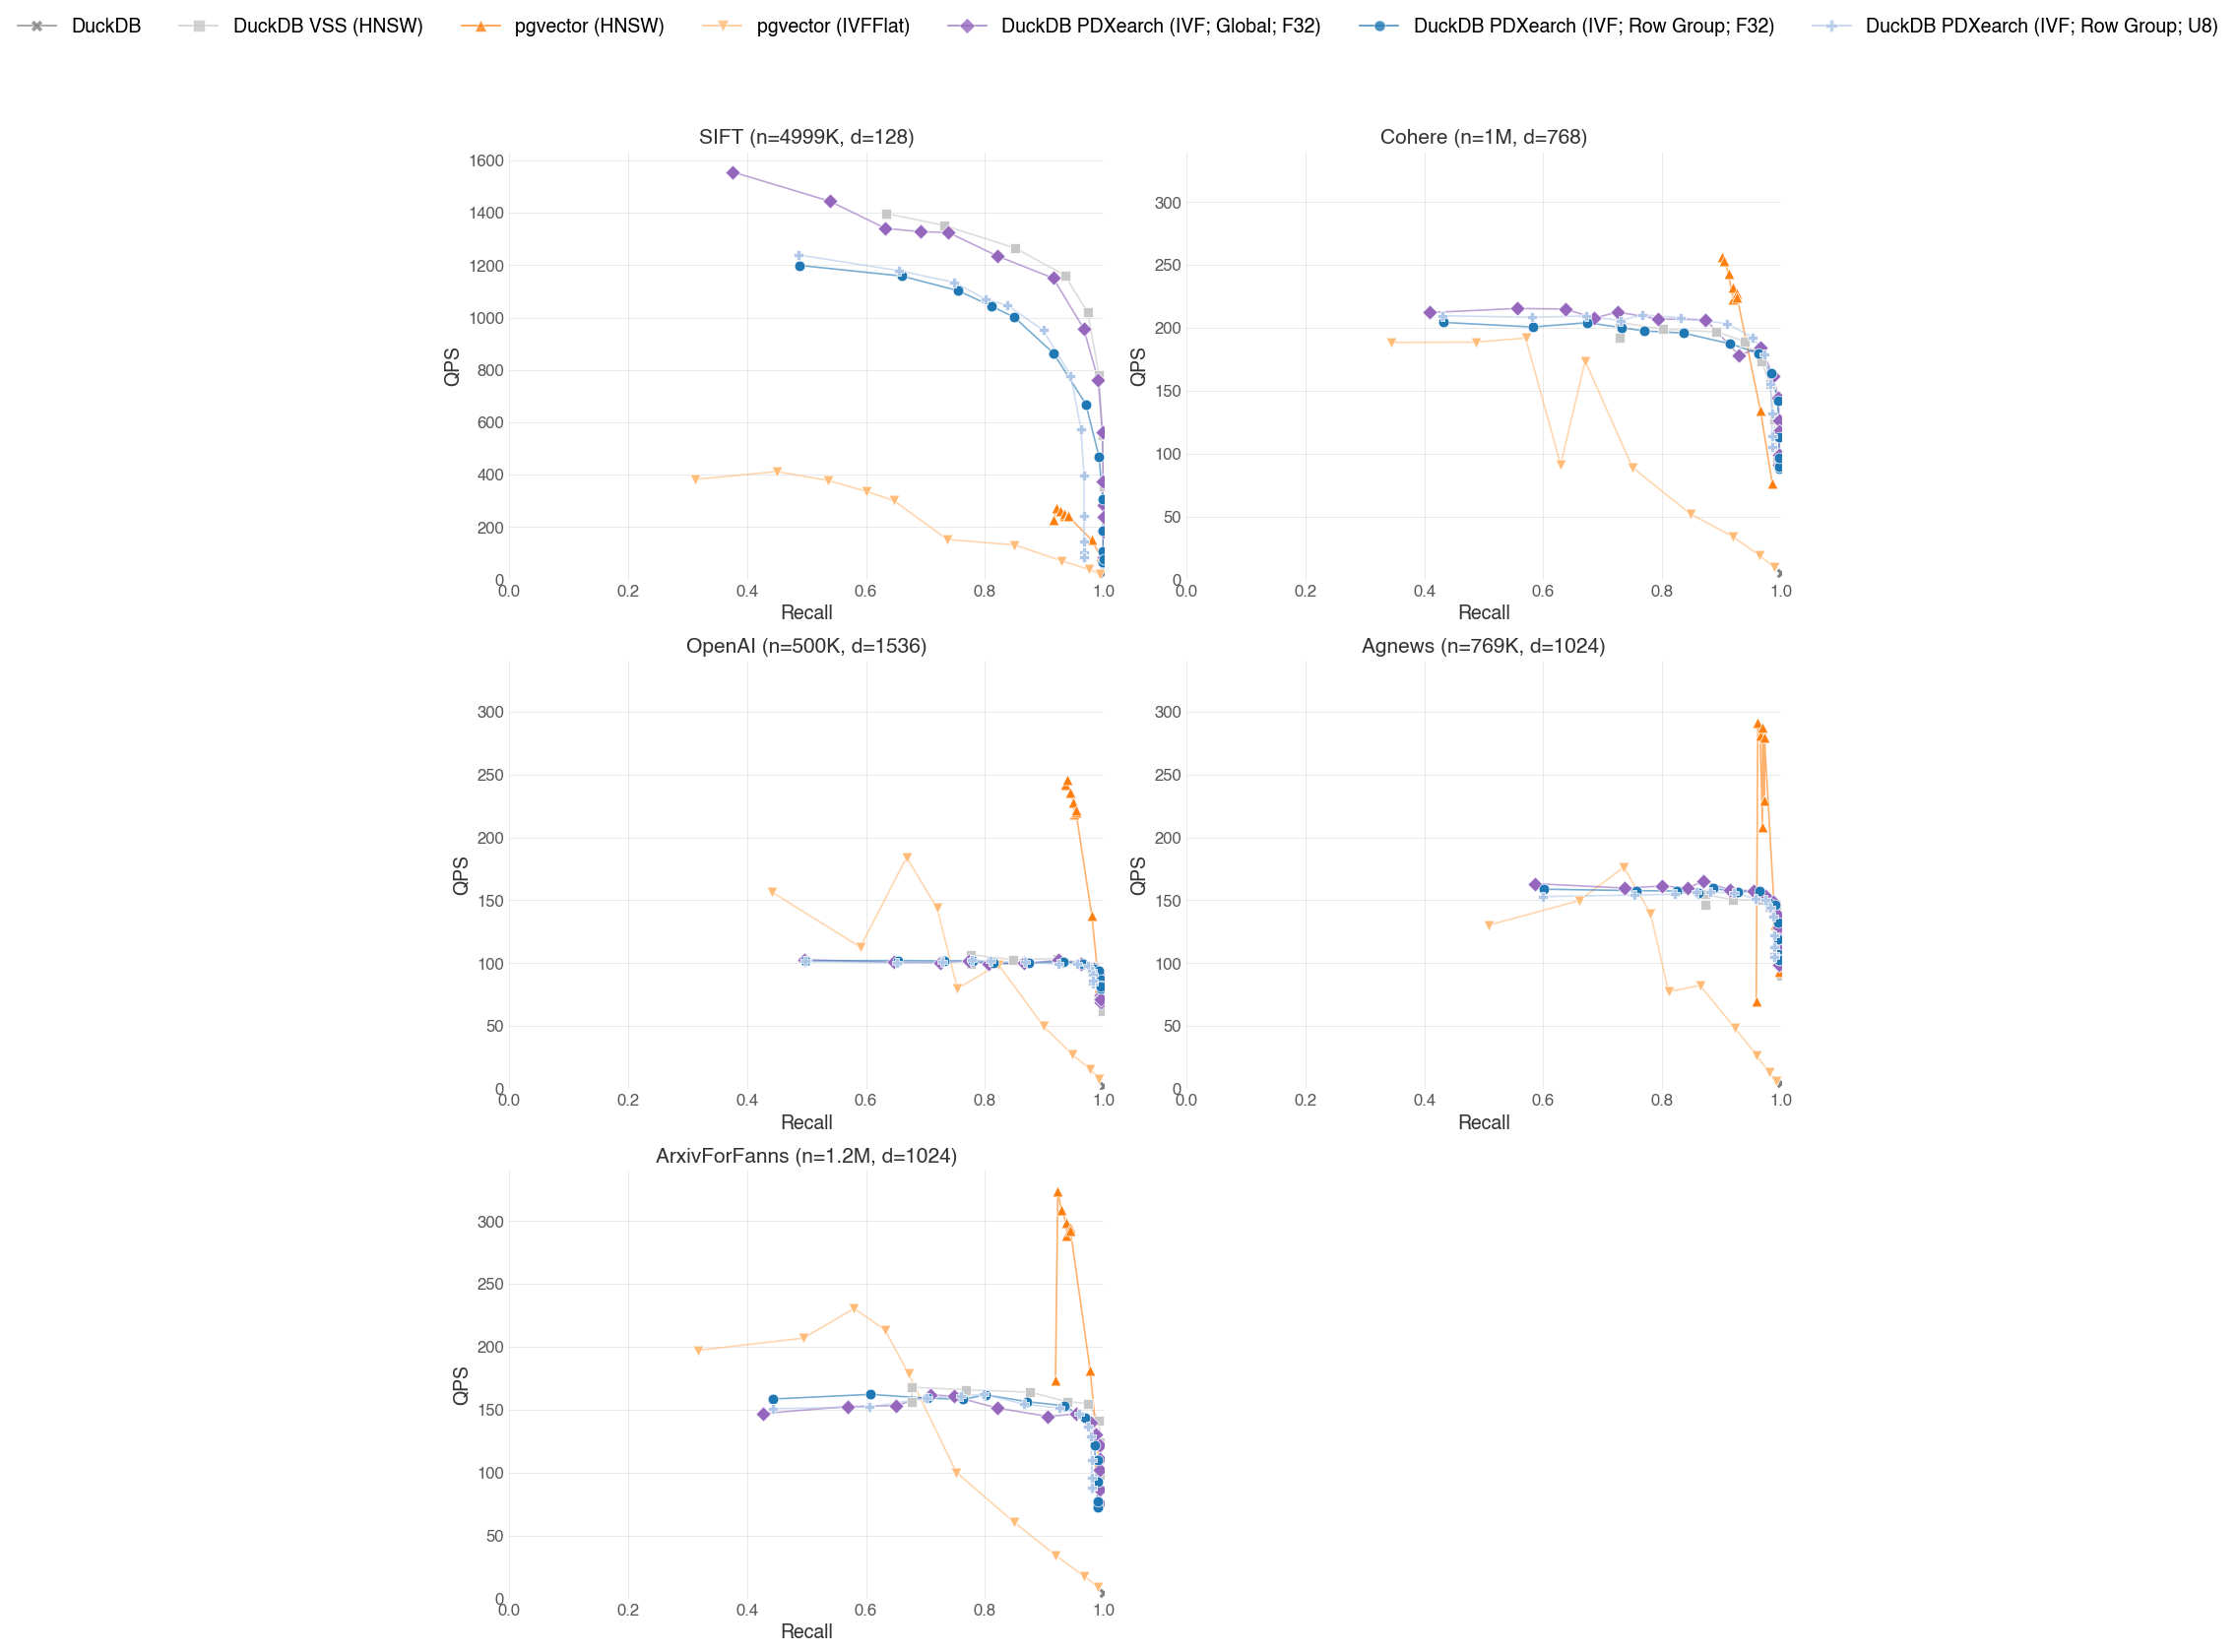

In [24]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per dataset
# ---------------------------------------------------------------------------
from collections import defaultdict
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

apply_style()

# Group records: dataset → index_type → list of (recall, qps) tuples
grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))

for r in records:
    grouped[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"]))

# Get all unique index types present in the data
all_index_types = set()
for dataset in datasets:
    all_index_types.update(grouped[dataset].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

# Compute y-axis ranges: shared across non-SIFT datasets, per-dataset for SIFT
non_sift_qps = []
per_dataset_qps: dict[str, list[float]] = defaultdict(list)
for dataset in datasets:
    for index_type in all_index_types:
        points = grouped[dataset].get(index_type, [])
        qps_values = [qps for recall, qps in points]
        per_dataset_qps[dataset].extend(qps_values)
        if "SIFT" not in dataset:
            non_sift_qps.extend(qps_values)

non_sift_y_max = max(non_sift_qps) if non_sift_qps else 1
non_sift_ylim = (0, non_sift_y_max * 1.05)

def get_ylim(dataset: str) -> tuple[float, float]:
    if "SIFT" in dataset:
        ds_qps = per_dataset_qps.get(dataset, [])
        ds_y_max = max(ds_qps) if ds_qps else 1
        return (0, ds_y_max * 1.05)
    return non_sift_ylim

# Create subplots: one per dataset
n_datasets = len(datasets)
n_cols = min(n_datasets, 2)
n_rows = (n_datasets + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows), squeeze=False)

for ds_idx, dataset in enumerate(datasets):
    row, col = divmod(ds_idx, n_cols)
    ax = axes[row][col]

    for index_type in all_index_types:
        points = grouped[dataset].get(index_type, [])
        if not points:
            continue

        # Filter out points with recall < 0.90 and sort by recall
        # points = [p for p in points if p[0] >= 0.90]
        # if not points:
        #     continue
        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]

        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")

        ax.scatter(recalls, qps_vals, label=index_type, color=color,
                   marker=marker, s=MARKER_SIZE, zorder=3, edgecolors='white', linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)

    ax.set_title(format_dataset_title(dataset), fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
    ax.set_ylabel("QPS", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)

    # Grids
    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Shared x-axis range across all subplots
    ax.set_xlim(0, 1)

    ax.set_ylim(get_ylim(dataset))

    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Hide any unused subplots
for idx in range(n_datasets, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

# Shared legend across all subplots
legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=len(all_index_types),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("index_search.pdf", dpi=PLOT_DPI, bbox_inches='tight')